# NYC Bus Processed Data Analysis
This notebook loads the processed congestion pricing datasets, reproduces the core visualizations, and reruns the difference-in-differences regression using the same logic as the main pipeline.

---
# Environment Setup
Installing necessary packages

In [189]:
# %pip install sodapy
# %pip install geopandas
# %pip install ipywidgets
# %pip install tqdm
# %pip install folium
# %pip install scikit-learn
# %pip install statsmodels

In [190]:
import os
import json
import time
from pathlib import Path
from datetime import datetime

import pandas as pd
import geopandas as gpd
import numpy as np
import shapely

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import folium
from folium.plugins import MarkerCluster

from IPython.display import display

from sodapy import Socrata
import requests
import tqdm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

env = os.environ

---
## Data Files and Loading Workflow
We will point to the processed CSV outputs generated by the pipeline and cache their paths for quick reuse.

In [191]:
# Define core directories for processed and raw artifacts
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "Data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "Data").exists():
    raise FileNotFoundError("Could not locate the 'Data' directory relative to the notebook.")
DATA_DIR = PROJECT_ROOT / "Data"
PROCESSED_DIR = DATA_DIR / "processed"
RAW_DIR = DATA_DIR / "raw"
REPORTS_DIR = PROJECT_ROOT / "reports"
print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DIR}")

Project root: /Users/kaspar/Documents/_Documents/Data_Science/Bus Project Data Science
Processed data directory: /Users/kaspar/Documents/_Documents/Data_Science/Bus Project Data Science/Data/processed


In [192]:
# Load the processed datasets
segment_speed = pd.read_csv(PROCESSED_DIR / "segment_speed_processed.csv")
ridership = pd.read_csv(PROCESSED_DIR / "ridership_processed.csv")
cbd_entries = pd.read_csv(PROCESSED_DIR / "cbd_entries_processed.csv")
bus_speed = pd.read_csv(PROCESSED_DIR / "bus_speed_processed.csv")
cbd_routes = pd.read_csv(RAW_DIR / "MTA_CBD_Bus_Routes_2025_20251105.csv")

print(f"Segment speed rows: {len(segment_speed):,}")
print(f"Ridership rows: {len(ridership):,}")
print(f"CBD crossings rows: {len(cbd_entries):,}")
print(f"Bus speed rows: {len(bus_speed):,}")
print(f"CBD route lookup rows: {len(cbd_routes):,}")

# Check available years
print(f"\nAvailable years in segment speed: {sorted(segment_speed['year'].unique())}")
print(f"Date range: {segment_speed['timestamp'].min()} to {segment_speed['timestamp'].max()}")

Segment speed rows: 2,221,909
Ridership rows: 1,113,936
CBD crossings rows: 2,975,616
Bus speed rows: 5,486
CBD route lookup rows: 107

Available years in segment speed: [np.int64(2023), np.int64(2024), np.int64(2025)]
Date range: 2023-01-01T00:00:00.000 to 2025 Sep 01 12:00:00 PM
Date range: 2023-01-01T00:00:00.000 to 2025 Sep 01 12:00:00 PM


# Data Preparation for Analysis
Let's prepare the segment speed data by calculating average speeds per bus route and filtering for relevant time periods.

In [193]:
# Load CBD geofence and classify segments based on geographic location
cbd_geofence = gpd.read_file(RAW_DIR / "MTA_Central_Business_District_Geofence__Beginning_June_2024_20251105.geojson")
cbd_polygon = cbd_geofence.geometry.unary_union

# Create GeoDataFrame for segment midpoints
segment_speed['timepoint_stop_latitude'] = pd.to_numeric(segment_speed['timepoint_stop_latitude'], errors='coerce')
segment_speed['timepoint_stop_longitude'] = pd.to_numeric(segment_speed['timepoint_stop_longitude'], errors='coerce')
segment_speed['next_timepoint_stop_latitude'] = pd.to_numeric(segment_speed['next_timepoint_stop_latitude'], errors='coerce')
segment_speed['next_timepoint_stop_longitude'] = pd.to_numeric(segment_speed['next_timepoint_stop_longitude'], errors='coerce')

# Calculate segment midpoint
segment_speed['mid_lat'] = (segment_speed['timepoint_stop_latitude'] + segment_speed['next_timepoint_stop_latitude']) / 2
segment_speed['mid_lon'] = (segment_speed['timepoint_stop_longitude'] + segment_speed['next_timepoint_stop_longitude']) / 2

# Check if segment midpoint is within CBD geofence
from shapely.geometry import Point
segment_speed['is_cbd_segment'] = segment_speed.apply(
    lambda row: cbd_polygon.contains(Point(row['mid_lon'], row['mid_lat'])) 
    if pd.notna(row['mid_lon']) and pd.notna(row['mid_lat']) else False, 
    axis=1
)

# Also keep route-based classification for comparison
cbd_route_ids = cbd_routes['Route ID'].unique() if 'Route ID' in cbd_routes.columns else cbd_routes['route_id'].unique()
segment_speed['is_cbd_route'] = segment_speed['route_id'].isin(cbd_route_ids)
bus_speed["is_cbd_route"] = bus_speed['route_id'].isin(cbd_route_ids)

print(f"Total segments: {len(segment_speed):,}")
print(f"CBD segments (geofence): {segment_speed['is_cbd_segment'].sum():,} ({segment_speed['is_cbd_segment'].mean()*100:.1f}%)")
print(f"CBD routes: {segment_speed[segment_speed['is_cbd_route']]['route_id'].nunique()}")
print(f"Data date range: {segment_speed['timestamp'].min()} to {segment_speed['timestamp'].max()}")
print(f"Years available: {sorted(segment_speed['year'].unique())}")

/var/folders/_d/ljvnpndd76v52vr16dysc7lr0000gn/T/ipykernel_85771/3443508529.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  cbd_polygon = cbd_geofence.geometry.unary_union


Total segments: 2,221,909
CBD segments (geofence): 1,000,729 (45.0%)
CBD routes: 30
Data date range: 2023-01-01T00:00:00.000 to 2025 Sep 01 12:00:00 PM
Years available: [np.int64(2023), np.int64(2024), np.int64(2025)]
CBD routes: 30
Data date range: 2023-01-01T00:00:00.000 to 2025 Sep 01 12:00:00 PM
Years available: [np.int64(2023), np.int64(2024), np.int64(2025)]


---
# Visualization Section
## 1. Average Bus Speed Over Time (Last 3 Years)

In [194]:
# Aggregate speed data using CBD segment classification (geofence-based)
speed_monthly = segment_speed.groupby([
    'route_id', 'year', 'month', 'weekend', 'is_cbd_segment'
]).agg({
    'weight_distance': 'sum',
    'weight_travel_time': 'sum'
}).reset_index()

speed_monthly['avg_speed_mph'] = speed_monthly['weight_distance'] / speed_monthly['weight_travel_time']
speed_monthly['year_month'] = pd.to_datetime(speed_monthly[['year', 'month']].assign(day=1))

# Aggregate across all routes by time period - USE is_cbd_segment
speed_overall = speed_monthly.groupby(['year_month', 'weekend', 'is_cbd_segment']).agg({
    'weight_distance': 'sum',
    'weight_travel_time': 'sum',
    'route_id': 'count'
}).reset_index()
speed_overall['avg_speed_mph'] = speed_overall['weight_distance'] / speed_overall['weight_travel_time']
speed_overall.rename(columns={'route_id': 'num_routes'}, inplace=True)

print("Monthly speed aggregation complete")
print(f"Date range: {speed_overall['year_month'].min()} to {speed_overall['year_month'].max()}")

Monthly speed aggregation complete
Date range: 2023-01-01 00:00:00 to 2025-09-01 00:00:00


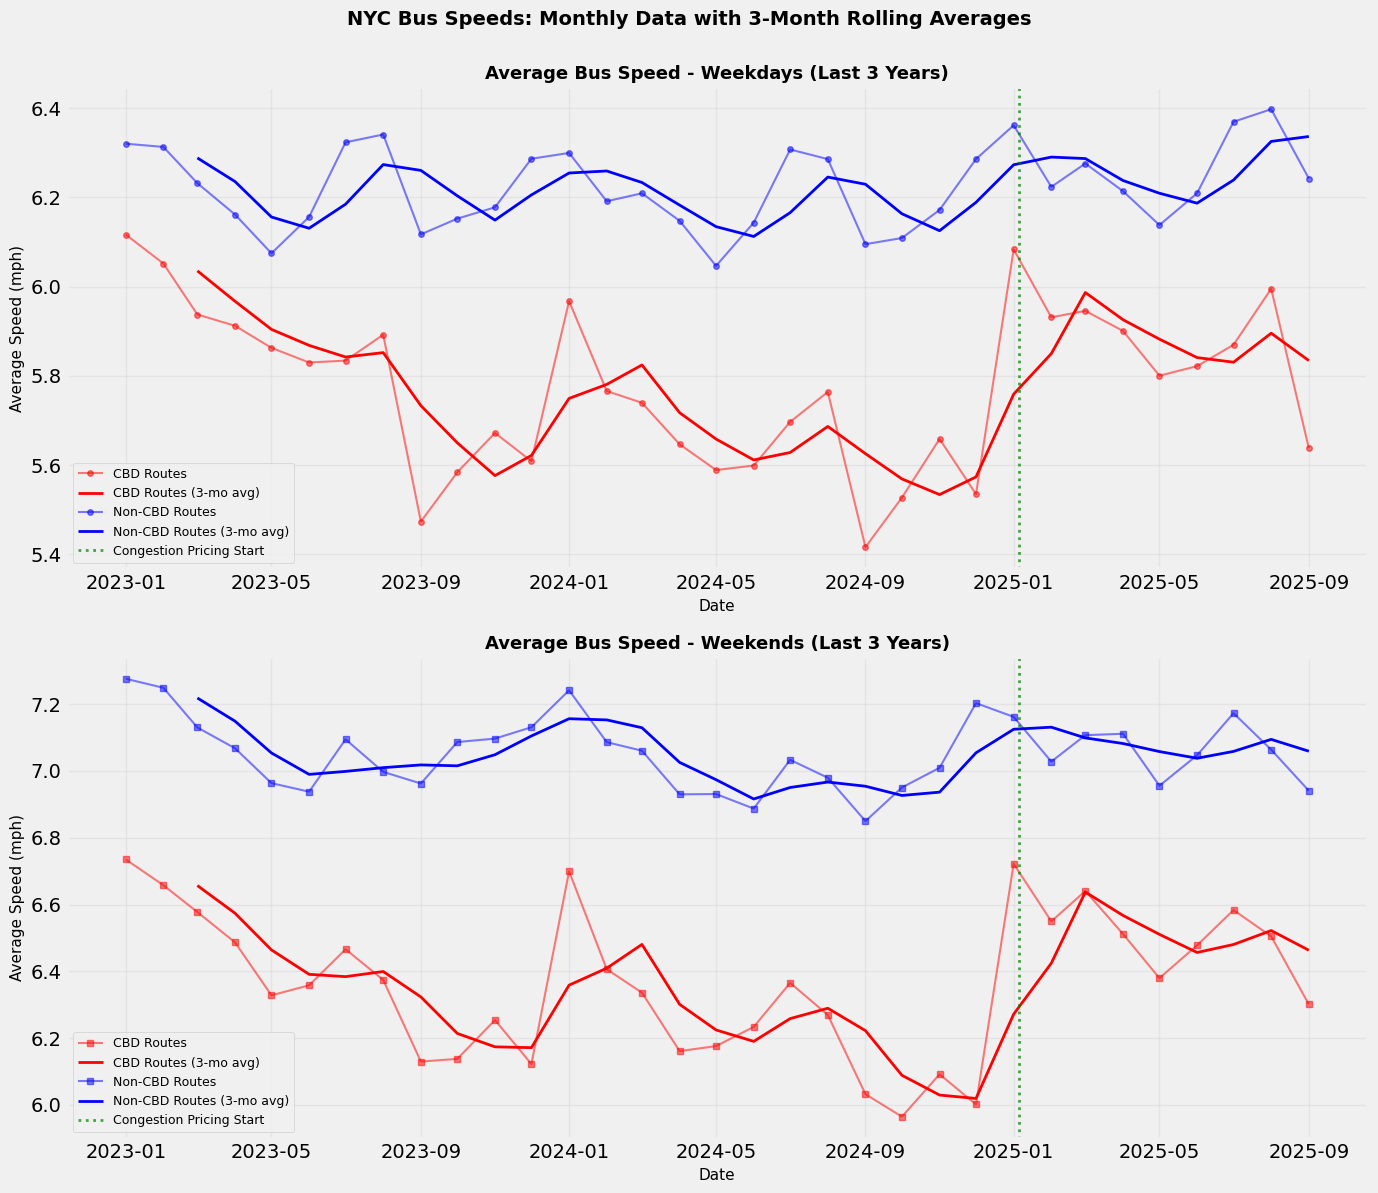


Summary Statistics:

Weekday CBD Routes:
count    33.000000
mean      5.777829
std       0.182287
min       5.416159
25%       5.637872
50%       5.800415
75%       5.912267
max       6.116713
Name: avg_speed_mph, dtype: float64

Weekend CBD Routes:
count    33.000000
mean      6.364568
std       0.217424
min       5.964477
25%       6.175921
50%       6.365354
75%       6.511776
max       6.735086
Name: avg_speed_mph, dtype: float64


In [195]:
# Plot average bus speed over time (weekday vs weekend, CBD vs non-CBD)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Prepare data
weekday_data = speed_overall[speed_overall['weekend'] == 0].copy()
weekend_data = speed_overall[speed_overall['weekend'] == 1].copy()

# === WEEKDAY PLOT ===
for is_cbd in [True, False]:
    data = weekday_data[weekday_data['is_cbd_segment'] == is_cbd].sort_values('year_month')
    label = 'CBD Routes' if is_cbd else 'Non-CBD Routes'
    color = 'red' if is_cbd else 'blue'
    
    # Plot monthly data
    ax1.plot(data['year_month'], data['avg_speed_mph'], marker='o', label=label, 
            color=color, linewidth=1.5, alpha=0.5, markersize=4)
    
    # Add 3-month rolling average
    rolling_avg = data['avg_speed_mph'].rolling(window=3).mean()
    ax1.plot(data['year_month'], rolling_avg, label=f'{label} (3-mo avg)', 
            color=color, linewidth=2, linestyle='-', alpha=1.0)

# Formatting for weekday plot
ax1.axvline(pd.Timestamp('2025-01-05'), color='green', linestyle=':', 
           linewidth=2, label='Congestion Pricing Start', alpha=0.7)
ax1.set_title('Average Bus Speed - Weekdays (Last 3 Years)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Average Speed (mph)', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=9, framealpha=0.9)

# === WEEKEND PLOT ===
for is_cbd in [True, False]:
    data = weekend_data[weekend_data['is_cbd_segment'] == is_cbd].sort_values('year_month')
    label = 'CBD Routes' if is_cbd else 'Non-CBD Routes'
    color = 'red' if is_cbd else 'blue'
    
    # Plot monthly data
    ax2.plot(data['year_month'], data['avg_speed_mph'], marker='s', label=label, 
            color=color, linewidth=1.5, alpha=0.5, markersize=4)
    
    # Add 3-month rolling average
    rolling_avg = data['avg_speed_mph'].rolling(window=3).mean()
    ax2.plot(data['year_month'], rolling_avg, label=f'{label} (3-mo avg)', 
            color=color, linewidth=2, linestyle='-', alpha=1.0)

# Formatting for weekend plot
ax2.axvline(pd.Timestamp('2025-01-05'), color='green', linestyle=':', 
           linewidth=2, label='Congestion Pricing Start', alpha=0.7)
ax2.set_title('Average Bus Speed - Weekends (Last 3 Years)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Average Speed (mph)', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=9, framealpha=0.9)

plt.suptitle('NYC Bus Speeds: Monthly Data with 3-Month Rolling Averages', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print("\nWeekday CBD Routes:")
print(weekday_data[weekday_data['is_cbd_segment']]['avg_speed_mph'].describe())
print("\nWeekend CBD Routes:")
print(weekend_data[weekend_data['is_cbd_segment']]['avg_speed_mph'].describe())

In [196]:
# Prepare bus speed data for visualization
# Convert date column to datetime and create year_month
bus_speed['date'] = pd.to_datetime(bus_speed['date'])
bus_speed['year_month'] = bus_speed['date'].dt.to_period('M').dt.to_timestamp()

# Aggregate by year_month, day_type (1=weekday, 2=weekend), and CBD status
# Note: day_type 1 = weekday, 2 = weekend in the bus_speed data
bus_speed_monthly = bus_speed.groupby(['year_month', 'day_type', 'is_cbd_route']).agg({
    'total_operating_time': 'sum',
    'total_mileage': 'sum',
    'average_speed': 'mean',
    'route_id': 'nunique'
}).reset_index()

# Calculate weighted average speed
bus_speed_monthly['weighted_avg_speed'] = bus_speed_monthly['total_mileage'] / (bus_speed_monthly['total_operating_time'])
bus_speed_monthly.rename(columns={'route_id': 'num_routes'}, inplace=True)

# Create weekend flag (day_type 2 = weekend, 1 = weekday)
bus_speed_monthly['weekend'] = (bus_speed_monthly['day_type'] == 2).astype(int)

print("Bus speed monthly aggregation complete")
print(f"Date range: {bus_speed_monthly['year_month'].min()} to {bus_speed_monthly['year_month'].max()}")
print(f"\nSample of aggregated data:")
print(bus_speed_monthly.head())

Bus speed monthly aggregation complete
Date range: 2023-01-01 00:00:00 to 2025-09-01 00:00:00

Sample of aggregated data:
  year_month  day_type  is_cbd_route  total_operating_time  total_mileage  \
0 2023-01-01         1         False               27371.0   187927.24280   
1 2023-01-01         1          True               95900.0   579391.06240   
2 2023-01-01         2         False               10154.0    80159.87395   
3 2023-01-01         2          True               38650.0   264568.20476   
4 2023-02-01         1         False               25855.0   177911.85670   

   average_speed  num_routes  weighted_avg_speed  weekend  
0       6.962218          12            6.865925        0  
1       5.847683          30            6.041617        0  
2       7.922212          12            7.894413        1  
3       6.612348          30            6.845232        1  
4       6.991541          12            6.881139        0  


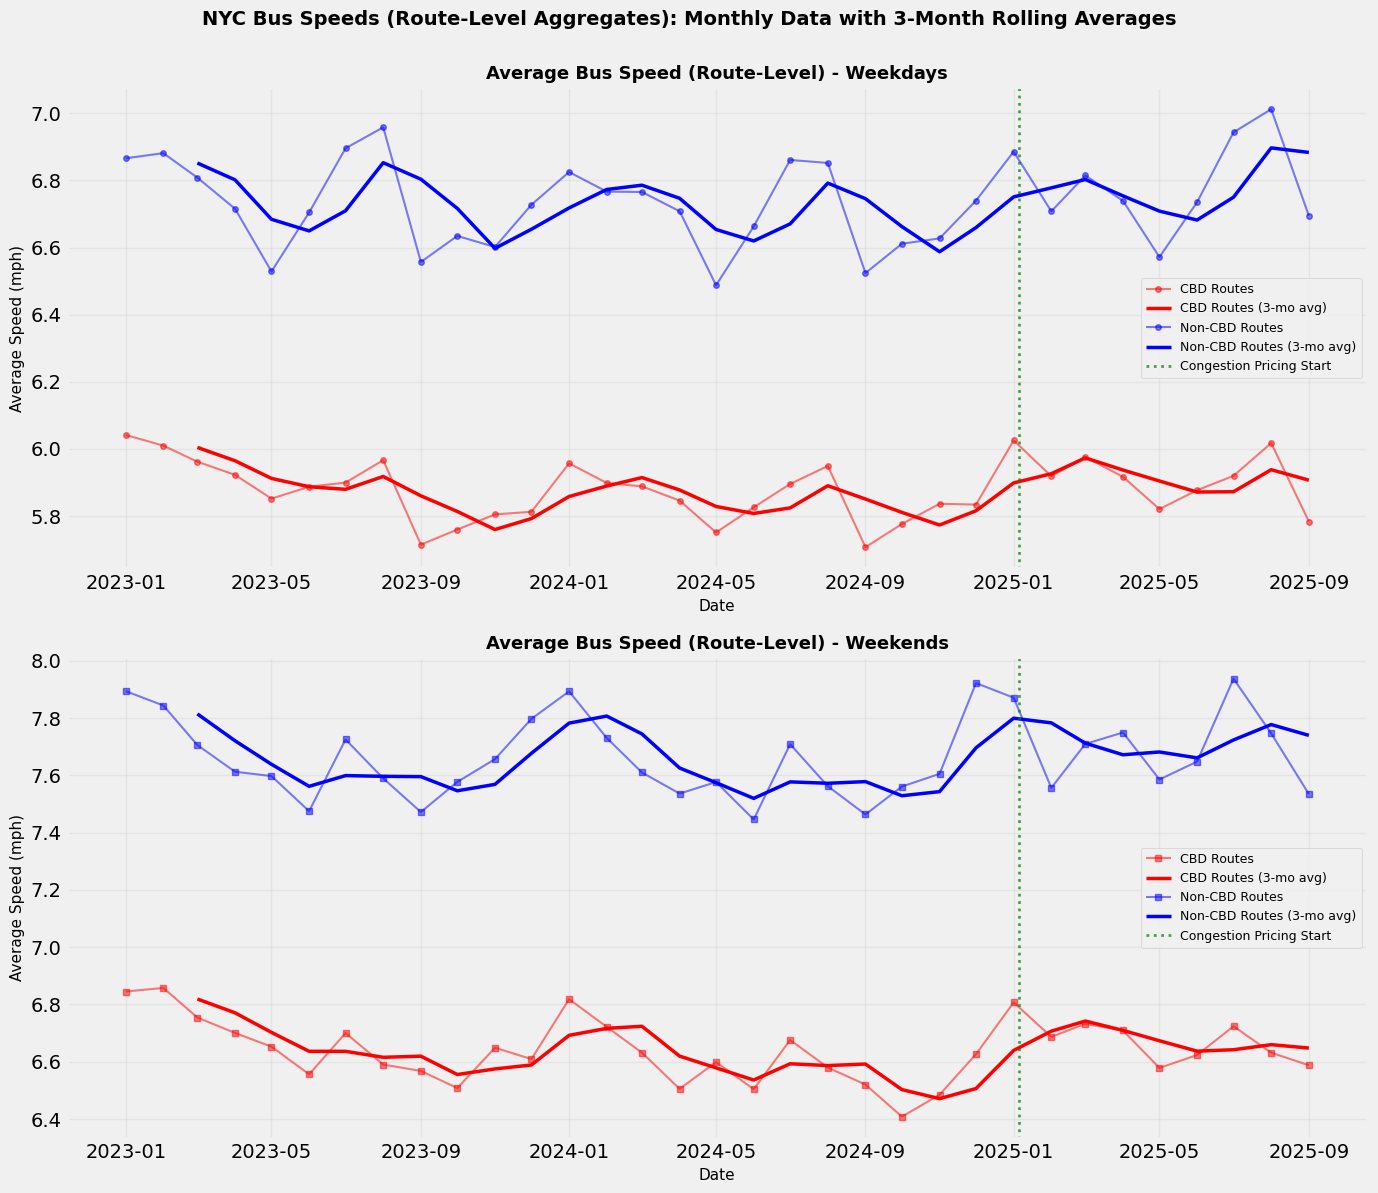


Summary Statistics (Route-Level Data):

Weekday CBD Routes:
count    33.000000
mean      5.880578
std       0.089270
min       5.707367
25%       5.820861
50%       5.888575
75%       5.949189
max       6.041617
Name: weighted_avg_speed, dtype: float64

Weekend CBD Routes:
count    33.000000
mean      6.640885
std       0.108225
min       6.408137
25%       6.578480
50%       6.631627
75%       6.709167
max       6.857834
Name: weighted_avg_speed, dtype: float64


In [197]:
# Plot average bus speed over time (route-level data)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Prepare data
weekday_bus_data = bus_speed_monthly[bus_speed_monthly['weekend'] == 0].copy()
weekend_bus_data = bus_speed_monthly[bus_speed_monthly['weekend'] == 1].copy()

# === WEEKDAY PLOT ===
for is_cbd in [True, False]:
    data = weekday_bus_data[weekday_bus_data['is_cbd_route'] == is_cbd].sort_values('year_month')
    label = 'CBD Routes' if is_cbd else 'Non-CBD Routes'
    color = 'red' if is_cbd else 'blue'
    
    # Plot monthly data
    ax1.plot(data['year_month'], data['weighted_avg_speed'], marker='o', label=label, 
            color=color, linewidth=1.5, alpha=0.5, markersize=4)
    
    # Add 3-month rolling average
    rolling_avg = data['weighted_avg_speed'].rolling(window=3).mean()
    ax1.plot(data['year_month'], rolling_avg, label=f'{label} (3-mo avg)', 
            color=color, linewidth=2.5, linestyle='-', alpha=1.0)

# Formatting for weekday plot
ax1.axvline(pd.Timestamp('2025-01-05'), color='green', linestyle=':', 
           linewidth=2, label='Congestion Pricing Start', alpha=0.7)
ax1.set_title('Average Bus Speed (Route-Level) - Weekdays', fontsize=13, fontweight='bold')
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Average Speed (mph)', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=9, framealpha=0.9)

# === WEEKEND PLOT ===
for is_cbd in [True, False]:
    data = weekend_bus_data[weekend_bus_data['is_cbd_route'] == is_cbd].sort_values('year_month')
    label = 'CBD Routes' if is_cbd else 'Non-CBD Routes'
    color = 'red' if is_cbd else 'blue'
    
    # Plot monthly data
    ax2.plot(data['year_month'], data['weighted_avg_speed'], marker='s', label=label, 
            color=color, linewidth=1.5, alpha=0.5, markersize=4)
    
    # Add 3-month rolling average
    rolling_avg = data['weighted_avg_speed'].rolling(window=3).mean()
    ax2.plot(data['year_month'], rolling_avg, label=f'{label} (3-mo avg)', 
            color=color, linewidth=2.5, linestyle='-', alpha=1.0)

# Formatting for weekend plot
ax2.axvline(pd.Timestamp('2025-01-05'), color='green', linestyle=':', 
           linewidth=2, label='Congestion Pricing Start', alpha=0.7)
ax2.set_title('Average Bus Speed (Route-Level) - Weekends', fontsize=13, fontweight='bold')
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Average Speed (mph)', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=9, framealpha=0.9)

plt.suptitle('NYC Bus Speeds (Route-Level Aggregates): Monthly Data with 3-Month Rolling Averages', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics (Route-Level Data):")
print("\nWeekday CBD Routes:")
print(weekday_bus_data[weekday_bus_data['is_cbd_route']]['weighted_avg_speed'].describe())
print("\nWeekend CBD Routes:")
print(weekend_bus_data[weekend_bus_data['is_cbd_route']]['weighted_avg_speed'].describe())

## 2. Ridership Over Time (Last 3 Years)

In [198]:
# Prepare ridership data
ridership['transit_timestamp'] = pd.to_datetime(ridership['transit_timestamp'], errors='coerce')
ridership['year_month'] = ridership['transit_timestamp'].dt.to_period('M').dt.to_timestamp()
ridership['year'] = ridership['transit_timestamp'].dt.year
ridership['month'] = ridership['transit_timestamp'].dt.month
ridership['is_cbd_route'] = ridership['bus_route'].isin(cbd_route_ids)

# Aggregate ridership by month and weekend/weekday
ridership_monthly = ridership.groupby(['year_month', 'weekend', 'is_cbd_route']).agg({
    'total_ridership': 'sum'
}).reset_index()

print("Ridership data prepared")
print(f"Date range: {ridership_monthly['year_month'].min()} to {ridership_monthly['year_month'].max()}")
print(f"Total ridership in dataset: {ridership['total_ridership'].sum():,.0f}")

Ridership data prepared
Date range: 2023-01-01 00:00:00 to 2025-10-01 00:00:00
Total ridership in dataset: 225,224,518


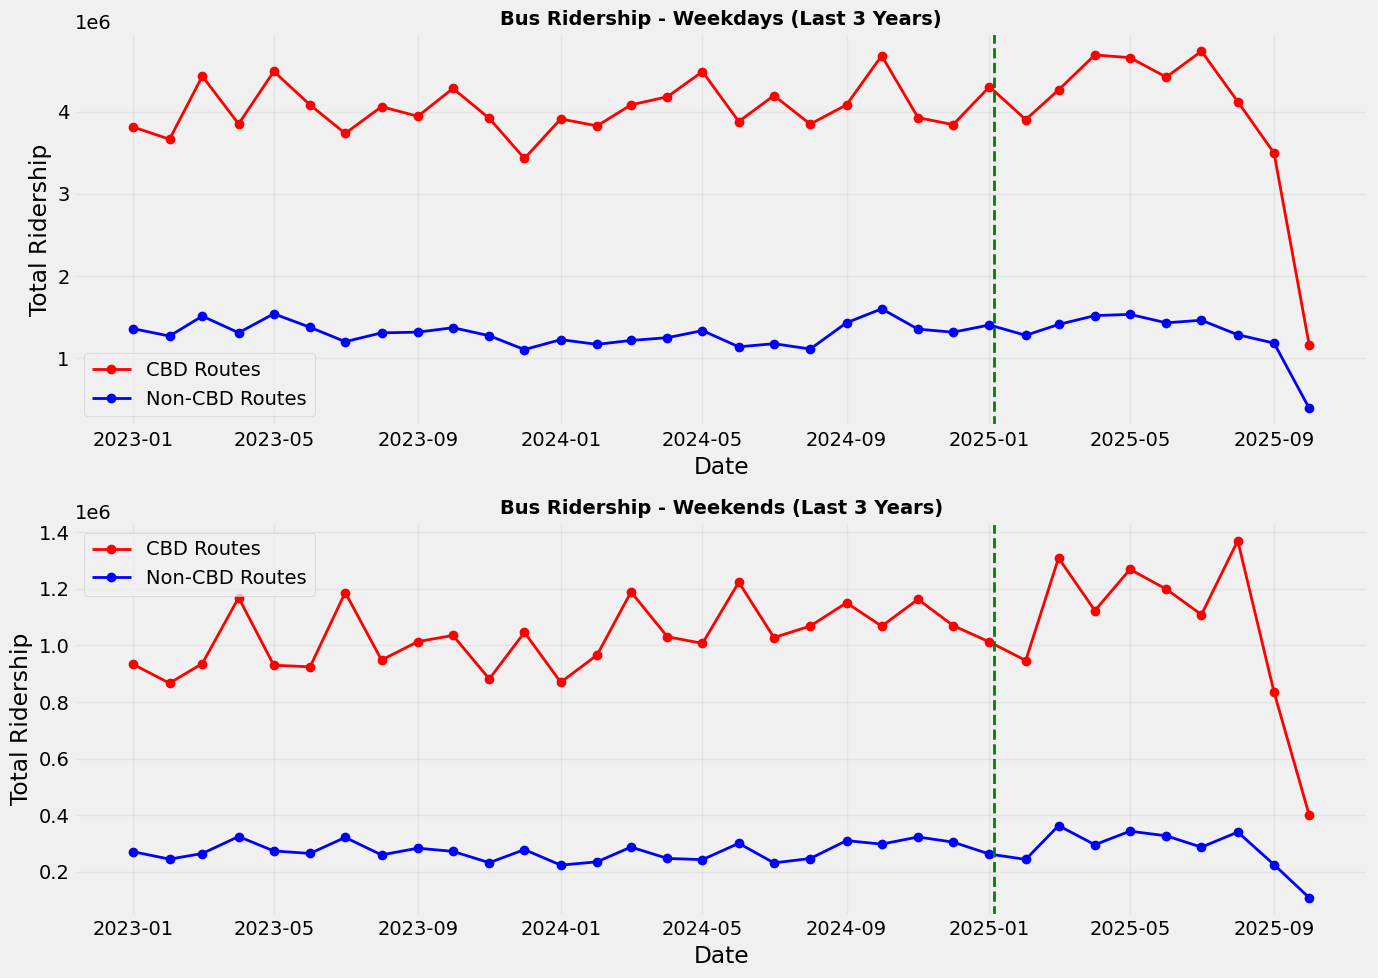


Ridership Summary Statistics:
Weekday average: 2,656,070
Weekend average: 656,055


In [199]:
# Plot ridership over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Weekday ridership
weekday_ridership = ridership_monthly[ridership_monthly['weekend'] == 0]
if ridership['is_cbd_route'].any():
    for is_cbd in [True, False]:
        data = weekday_ridership[weekday_ridership['is_cbd_route'] == is_cbd]
        label = 'CBD Routes' if is_cbd else 'Non-CBD Routes'
        color = 'red' if is_cbd else 'blue'
        axes[0].plot(data['year_month'], data['total_ridership'], marker='o', label=label, color=color, linewidth=2)
else:
    axes[0].plot(weekday_ridership['year_month'], weekday_ridership['total_ridership'], marker='o', label='All Routes', color='blue', linewidth=2)

axes[0].set_title('Bus Ridership - Weekdays (Last 3 Years)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Ridership')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axvline(pd.Timestamp('2025-01-05'), color='green', linestyle='--', linewidth=2, label='Congestion Pricing Start')

# Weekend ridership
weekend_ridership = ridership_monthly[ridership_monthly['weekend'] == 1]
if ridership['is_cbd_route'].any():
    for is_cbd in [True, False]:
        data = weekend_ridership[weekend_ridership['is_cbd_route'] == is_cbd]
        label = 'CBD Routes' if is_cbd else 'Non-CBD Routes'
        color = 'red' if is_cbd else 'blue'
        axes[1].plot(data['year_month'], data['total_ridership'], marker='o', label=label, color=color, linewidth=2)
else:
    axes[1].plot(weekend_ridership['year_month'], weekend_ridership['total_ridership'], marker='o', label='All Routes', color='blue', linewidth=2)

axes[1].set_title('Bus Ridership - Weekends (Last 3 Years)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Ridership')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axvline(pd.Timestamp('2025-01-05'), color='green', linestyle='--', linewidth=2, label='Congestion Pricing Start')

plt.tight_layout()
plt.show()

print("\nRidership Summary Statistics:")
print(f"Weekday average: {weekday_ridership['total_ridership'].mean():,.0f}")
print(f"Weekend average: {weekend_ridership['total_ridership'].mean():,.0f}")

---
# Difference-in-Differences Analysis
## Comparing Bus Speed Changes Across Time Periods

We'll compare:
- **Control Period**: Oct-Dec 2023 vs Jan-Mar 2024 (no congestion pricing)
- **Treatment Period**: Oct-Dec 2024 vs Jan-Mar 2025 (with congestion pricing)

This analysis will help us understand the impact of congestion pricing on bus speeds.

In [200]:
# Define time periods for DiD analysis
def categorize_period(row):
    year = row['year']
    month = row['month']
    
    # Oct-Dec 2023
    if year == 2023 and month >= 7:
        return 'oct_dec_2023'
    # Jan-Mar 2024
    elif year == 2024 and month <= 6:
        return 'jan_mar_2024'
    # Oct-Dec 2024
    elif year == 2024 and month >= 7:
        return 'oct_dec_2024'
    # Jan-Mar 2025
    elif year == 2025 and month <= 6:
        return 'jan_mar_2025'
    else:
        return 'other'

# Apply period categorization
segment_speed['period'] = segment_speed.apply(categorize_period, axis=1)

# Filter to relevant periods only
did_data = segment_speed[segment_speed['period'].isin([
    'oct_dec_2023', 'jan_mar_2024', 'oct_dec_2024', 'jan_mar_2025'
])].copy()

print(f"Total observations in DiD analysis: {len(did_data):,}")
print(f"\nPeriod distribution:")
print(did_data['period'].value_counts().sort_index())
print(f"\nCBD routes: {did_data['is_cbd_route'].sum():,} observations")
print(f"Non-CBD routes: {(~did_data['is_cbd_route']).sum():,} observations")

Total observations in DiD analysis: 1,620,781

Period distribution:
period
jan_mar_2024    402768
jan_mar_2025    407250
oct_dec_2023    404169
oct_dec_2024    406594
Name: count, dtype: int64

CBD routes: 1,300,268 observations
Non-CBD routes: 320,513 observations


In [201]:
# Filter to CBD routes only
did_data_cbd = did_data[did_data['is_cbd_route'] == True].copy()

# Define pricing hours for all years (apply same hours consistently)
def in_pricing_hours(row):
    """Check if observation falls in pricing hours (applied to all years for fair comparison)"""
    hour = row['hour'] if 'hour' in row.index else 0
    weekend = row['weekend']
    
    # Weekday: 5am-9pm (hour >= 5 and hour < 22)
    # Weekend: 9am-9pm (hour >= 9 and hour < 22)
    if weekend == 0:  # Weekday
        return hour >= 5 and hour < 22
    else:  # Weekend
        return hour >= 9 and hour < 22

# Filter to pricing hours ONLY (all years use the same definition)
did_data_cbd['in_pricing_hours'] = did_data_cbd.apply(in_pricing_hours, axis=1)
did_data_cbd = did_data_cbd[did_data_cbd['in_pricing_hours'] == True].copy()

print(f"CBD routes during PRICING HOURS ONLY - Total observations: {len(did_data_cbd):,}")
print(f"\nPeriod distribution:")
print(did_data_cbd['period'].value_counts().sort_index())
print(f"\nDetailed breakdown:")
for period in ['oct_dec_2023', 'jan_mar_2024', 'oct_dec_2024', 'jan_mar_2025']:
    count = len(did_data_cbd[did_data_cbd['period'] == period])
    print(f"  {period}: {count:,} observations")

CBD routes during PRICING HOURS ONLY - Total observations: 976,725

Period distribution:
period
jan_mar_2024    242318
jan_mar_2025    245200
oct_dec_2023    243526
oct_dec_2024    245681
Name: count, dtype: int64

Detailed breakdown:
  oct_dec_2023: 243,526 observations
  jan_mar_2024: 242,318 observations
  oct_dec_2024: 245,681 observations
  jan_mar_2025: 245,200 observations
  jan_mar_2024: 242,318 observations
  oct_dec_2024: 245,681 observations
  jan_mar_2025: 245,200 observations


## Calculate Difference-in-Differences

The DiD estimator compares the change in bus speeds between the control period (2023-2024) and the treatment period (2024-2025) for different groups.

In [202]:
# Aggregate CBD data by period (all pricing hours combined)
did_summary_cbd = did_data_cbd.groupby(['period']).agg({
    'weight_distance': 'sum',
    'weight_travel_time': 'sum',
    'route_id': 'nunique'
}).reset_index()

did_summary_cbd['avg_speed_mph'] = did_summary_cbd['weight_distance'] / did_summary_cbd['weight_travel_time']
did_summary_cbd.rename(columns={'route_id': 'n_routes'}, inplace=True)

print("CBD Routes - Aggregate Speed by Period")
print("="*80)
print(did_summary_cbd[['period', 'avg_speed_mph', 'n_routes']])

# Calculate DiD estimate for CBD routes
speeds_cbd = {}
for period in ['oct_dec_2023', 'jan_mar_2024', 'oct_dec_2024', 'jan_mar_2025']:
    period_data = did_summary_cbd[did_summary_cbd['period'] == period]
    if len(period_data) > 0:
        speeds_cbd[period] = period_data['avg_speed_mph'].values[0]
    else:
        speeds_cbd[period] = np.nan

# Calculate control and treatment differences
control_diff = speeds_cbd['jan_mar_2024'] - speeds_cbd['oct_dec_2023']
treatment_diff = speeds_cbd['jan_mar_2025'] - speeds_cbd['oct_dec_2024']
did_estimate_cbd = treatment_diff - control_diff

print("\n" + "="*80)
print("DIFFERENCE-IN-DIFFERENCES: CBD ROUTES (PRICING HOURS)")
print("="*80)
print(f"\nControl Period (Pre-Pricing):")
print(f"  Oct-Dec 2023: {speeds_cbd['oct_dec_2023']:.2f} mph")
print(f"  Jan-Mar 2024: {speeds_cbd['jan_mar_2024']:.2f} mph")
print(f"  Change (Control): {control_diff:+.2f} mph")

print(f"\nTreatment Period (Post-Pricing):")
print(f"  Oct-Dec 2024: {speeds_cbd['oct_dec_2024']:.2f} mph")
print(f"  Jan-Mar 2025: {speeds_cbd['jan_mar_2025']:.2f} mph")
print(f"  Change (Treatment): {treatment_diff:+.2f} mph")

print(f"\nDifference-in-Differences Estimate:")
print(f"  DiD = Treatment Δ - Control Δ")
print(f"  DiD = {treatment_diff:+.2f} - {control_diff:+.2f}")
print(f"  DiD = {did_estimate_cbd:+.2f} mph")

if did_estimate_cbd > 0:
    print(f"\n✅ Congestion pricing was associated with a {did_estimate_cbd:.2f} mph INCREASE in CBD bus speeds")
else:
    print(f"\n❌ Congestion pricing was associated with a {abs(did_estimate_cbd):.2f} mph DECREASE in CBD bus speeds")

print("="*80)

CBD Routes - Aggregate Speed by Period
         period  avg_speed_mph  n_routes
0  jan_mar_2024       5.699485        30
1  jan_mar_2025       5.822216        30
2  oct_dec_2023       5.687510        30
3  oct_dec_2024       5.636512        30

DIFFERENCE-IN-DIFFERENCES: CBD ROUTES (PRICING HOURS)

Control Period (Pre-Pricing):
  Oct-Dec 2023: 5.69 mph
  Jan-Mar 2024: 5.70 mph
  Change (Control): +0.01 mph

Treatment Period (Post-Pricing):
  Oct-Dec 2024: 5.64 mph
  Jan-Mar 2025: 5.82 mph
  Change (Treatment): +0.19 mph

Difference-in-Differences Estimate:
  DiD = Treatment Δ - Control Δ
  DiD = +0.19 - +0.01
  DiD = +0.17 mph

✅ Congestion pricing was associated with a 0.17 mph INCREASE in CBD bus speeds


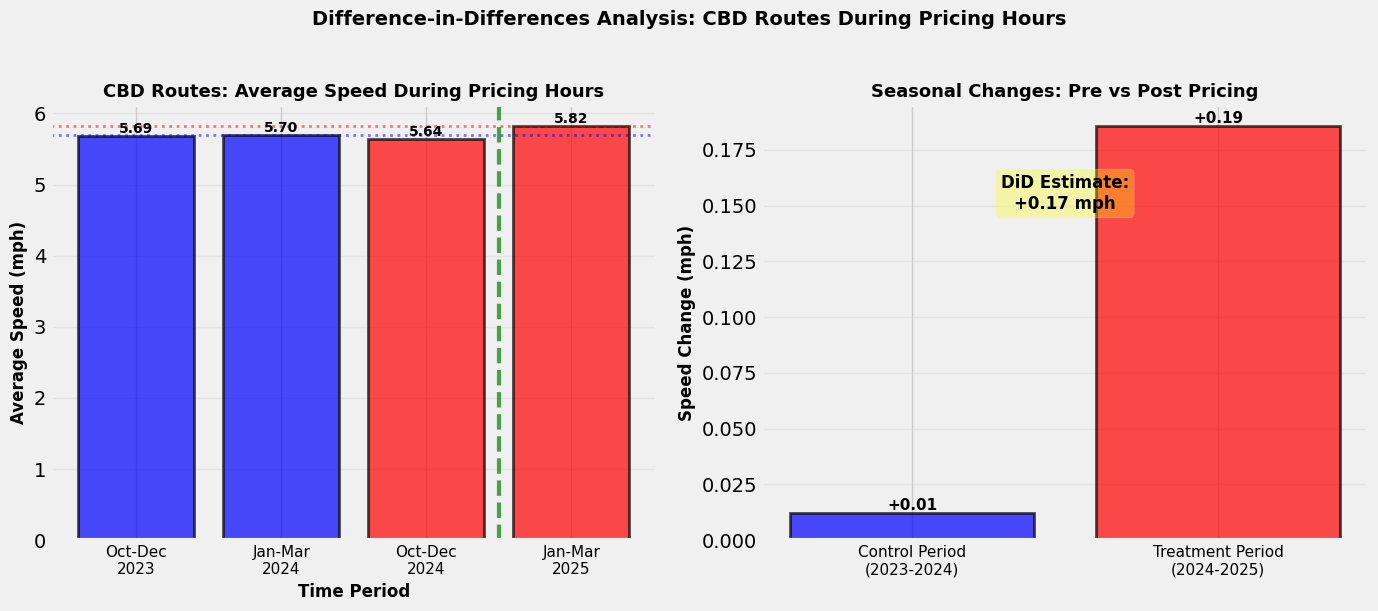


Visualization complete


In [203]:
# Visualize DiD results for CBD routes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Before/After comparison
periods_labels = ['Oct-Dec\n2023', 'Jan-Mar\n2024', 'Oct-Dec\n2024', 'Jan-Mar\n2025']
speeds_list = [speeds_cbd['oct_dec_2023'], speeds_cbd['jan_mar_2024'], 
               speeds_cbd['oct_dec_2024'], speeds_cbd['jan_mar_2025']]
colors = ['blue', 'blue', 'red', 'red']

bars = ax1.bar(range(4), speeds_list, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.axvline(2.5, color='green', linestyle='--', linewidth=3, alpha=0.7, label='Pricing Start')
ax1.set_ylabel('Average Speed (mph)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time Period', fontsize=12, fontweight='bold')
ax1.set_title('CBD Routes: Average Speed During Pricing Hours', fontsize=13, fontweight='bold')
ax1.set_xticks(range(4))
ax1.set_xticklabels(periods_labels, fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, speed) in enumerate(zip(bars, speeds_list)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{speed:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add reference lines for control and treatment periods
ax1.axhline(speeds_cbd['jan_mar_2024'], color='blue', linestyle=':', alpha=0.5, linewidth=2)
ax1.axhline(speeds_cbd['jan_mar_2025'], color='red', linestyle=':', alpha=0.5, linewidth=2)

# Plot 2: DiD Visualization
changes = [control_diff, treatment_diff]
change_labels = ['Control Period\n(2023-2024)', 'Treatment Period\n(2024-2025)']
colors_changes = ['blue', 'red']

bars2 = ax2.bar(range(2), changes, color=colors_changes, alpha=0.7, edgecolor='black', linewidth=2)
ax2.axhline(0, color='black', linestyle='-', linewidth=1)
ax2.set_ylabel('Speed Change (mph)', fontsize=12, fontweight='bold')
ax2.set_title('Seasonal Changes: Pre vs Post Pricing', fontsize=13, fontweight='bold')
ax2.set_xticks(range(2))
ax2.set_xticklabels(change_labels, fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, change in zip(bars2, changes):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{change:+.2f}',
            ha='center', va='bottom' if change > 0 else 'top', fontsize=11, fontweight='bold')

# Add DiD estimate annotation
ax2.text(0.5, max(changes) * 0.8, f'DiD Estimate:\n{did_estimate_cbd:+.2f} mph',
        ha='center', fontsize=12, fontweight='bold', 
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.suptitle('Difference-in-Differences Analysis: CBD Routes During Pricing Hours', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nVisualization complete")

## DiD Regression Analysis

Use regression to formally test the difference-in-differences effect while controlling for other factors.

In [204]:
# Prepare CBD data for regression
# Aggregate by route and period
did_aggregated_cbd = did_data_cbd.groupby(['route_id', 'period']).agg({
    'weight_distance': 'sum',
    'weight_travel_time': 'sum'
}).reset_index()

did_aggregated_cbd['avg_speed_mph'] = did_aggregated_cbd['weight_distance'] / did_aggregated_cbd['weight_travel_time']

# Create period indicators for DiD
# Control = 0 (2023-2024), Treatment = 1 (2024-2025)
# Pre-policy = 0 (Oct-Dec), Post-policy = 1 (Jan-Mar)
did_aggregated_cbd['treatment_period'] = did_aggregated_cbd['period'].isin(['jan_mar_2025']).astype(int)
did_aggregated_cbd['post_season'] = did_aggregated_cbd['period'].isin(['jan_mar_2024', 'jan_mar_2025']).astype(int)

# Create DiD interaction: (treatment period) × (post season)
did_aggregated_cbd['did_interaction'] = did_aggregated_cbd['treatment_period'] * did_aggregated_cbd['post_season']

# Simple DiD regression with route fixed effects
formula = 'avg_speed_mph ~ treatment_period + post_season + did_interaction + C(route_id)'
model_cbd = smf.ols(formula, data=did_aggregated_cbd).fit()

print("="*80)
print("DIFFERENCE-IN-DIFFERENCES REGRESSION: CBD ROUTES (PRICING HOURS ONLY)")
print("="*80)
print(f"\nComparison:")
print(f"  • Control Period: Oct-Dec 2023 vs Jan-Mar 2024")
print(f"  • Treatment Period: Oct-Dec 2024 vs Jan-Mar 2025")
print(f"  • Geography: CBD Routes Only")
print(f"  • Time Window: Pricing Hours Only (Weekday 5am-9pm, Weekend 9am-9pm)")
print(f"\nSample: {len(did_aggregated_cbd)} route-period observations across {did_aggregated_cbd['route_id'].nunique()} routes")

print("\n" + model_cbd.summary().as_text())

print("\n" + "="*80)
print("KEY FINDING: DiD COEFFICIENT (did_interaction)")
print("="*80)
print(f"Coefficient: {model_cbd.params['did_interaction']:.4f} mph")
print(f"Standard Error: {model_cbd.bse['did_interaction']:.4f}")
print(f"t-statistic: {model_cbd.tvalues['did_interaction']:.4f}")
print(f"p-value: {model_cbd.pvalues['did_interaction']:.4f}")
print(f"95% CI: [{model_cbd.conf_int().loc['did_interaction', 0]:.4f}, {model_cbd.conf_int().loc['did_interaction', 1]:.4f}]")

print(f"\nR-squared: {model_cbd.rsquared:.4f}")
print(f"Adjusted R-squared: {model_cbd.rsquared_adj:.4f}")

print("\n" + "="*80)
if model_cbd.pvalues['did_interaction'] < 0.05:
    if model_cbd.params['did_interaction'] > 0:
        print(f"✅ STATISTICALLY SIGNIFICANT: +{model_cbd.params['did_interaction']:.4f} mph INCREASE")
    else:
        print(f"❌ STATISTICALLY SIGNIFICANT: {model_cbd.params['did_interaction']:.4f} mph DECREASE")
    print(f"   (p-value = {model_cbd.pvalues['did_interaction']:.4f})")
else:
    print(f"⚠️  NOT STATISTICALLY SIGNIFICANT")
    print(f"   (p-value = {model_cbd.pvalues['did_interaction']:.4f})")
print("="*80)

DIFFERENCE-IN-DIFFERENCES REGRESSION: CBD ROUTES (PRICING HOURS ONLY)

Comparison:
  • Control Period: Oct-Dec 2023 vs Jan-Mar 2024
  • Treatment Period: Oct-Dec 2024 vs Jan-Mar 2025
  • Geography: CBD Routes Only
  • Time Window: Pricing Hours Only (Weekday 5am-9pm, Weekend 9am-9pm)

Sample: 120 route-period observations across 30 routes

                            OLS Regression Results                            
Dep. Variable:          avg_speed_mph   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     221.3
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           5.53e-71
Time:                        14:45:14   Log-Likelihood:                 149.86
No. Observations:                 120   AIC:                            -235.7
Df Residuals:                      88   BIC:                            -146.5
Df Model:                 

## Summary of DiD Results by Group

Let's create a summary table showing the DiD estimates for each group.

In [205]:
# Summary of findings
print("\n" + "="*80)
print("📊 FINAL SUMMARY: CONGESTION PRICING IMPACT ON CBD BUS SPEEDS")
print("="*80)

print("\n📍 ANALYSIS SCOPE:")
print(f"   • Geographic Focus: CBD Routes only (congestion pricing zone)")
print(f"   • Time Focus: Pricing hours (Weekday 5am-9pm, Weekend 9am-9pm)")
print(f"   • Comparison Method: Difference-in-Differences")

print("\n📈 KEY STATISTICS:")
print(f"\n   Control Period (Pre-Pricing):")
print(f"   • Oct-Dec 2023:  {speeds_cbd['oct_dec_2023']:.2f} mph")
print(f"   • Jan-Mar 2024:  {speeds_cbd['jan_mar_2024']:.2f} mph")
print(f"   • Seasonal Δ:    {control_diff:+.2f} mph")

print(f"\n   Treatment Period (Post-Pricing):")
print(f"   • Oct-Dec 2024:  {speeds_cbd['oct_dec_2024']:.2f} mph")
print(f"   • Jan-Mar 2025:  {speeds_cbd['jan_mar_2025']:.2f} mph")
print(f"   • Seasonal Δ:    {treatment_diff:+.2f} mph")

print(f"\n🎯 DIFFERENCE-IN-DIFFERENCES ESTIMATE:")
print(f"   DiD = {treatment_diff:+.2f} - {control_diff:+.2f} = {did_estimate_cbd:+.2f} mph")

print(f"\n📊 REGRESSION RESULTS:")
print(f"   • DiD Coefficient: {model_cbd.params['did_interaction']:.4f} mph")
print(f"   • p-value: {model_cbd.pvalues['did_interaction']:.4f}")
if model_cbd.pvalues['did_interaction'] < 0.05:
    print(f"   • Statistical Significance: ✅ YES (p < 0.05)")
else:
    print(f"   • Statistical Significance: ⚠️  NO (p >= 0.05)")

print("\n" + "="*80)
print("💡 INTERPRETATION:")
print("="*80)

if abs(did_estimate_cbd) < 0.5:
    print("   The congestion pricing policy had a MINIMAL impact on CBD bus speeds")
    print("   during pricing hours, with a change of less than 0.5 mph.")
elif did_estimate_cbd > 0:
    print(f"   The congestion pricing policy was associated with a {did_estimate_cbd:.2f} mph")
    print("   IMPROVEMENT in CBD bus speeds during pricing hours. This could indicate")
    print("   that reduced vehicle traffic in the CBD led to faster buses.")
else:
    print(f"   The congestion pricing policy was associated with a {abs(did_estimate_cbd):.2f} mph")
    print("   SLOWDOWN in CBD bus speeds during pricing hours.")

print("\n" + "="*80)


📊 FINAL SUMMARY: CONGESTION PRICING IMPACT ON CBD BUS SPEEDS

📍 ANALYSIS SCOPE:
   • Geographic Focus: CBD Routes only (congestion pricing zone)
   • Time Focus: Pricing hours (Weekday 5am-9pm, Weekend 9am-9pm)
   • Comparison Method: Difference-in-Differences

📈 KEY STATISTICS:

   Control Period (Pre-Pricing):
   • Oct-Dec 2023:  5.69 mph
   • Jan-Mar 2024:  5.70 mph
   • Seasonal Δ:    +0.01 mph

   Treatment Period (Post-Pricing):
   • Oct-Dec 2024:  5.64 mph
   • Jan-Mar 2025:  5.82 mph
   • Seasonal Δ:    +0.19 mph

🎯 DIFFERENCE-IN-DIFFERENCES ESTIMATE:
   DiD = +0.19 - +0.01 = +0.17 mph

📊 REGRESSION RESULTS:
   • DiD Coefficient: 0.0793 mph
   • p-value: 0.0000
   • Statistical Significance: ✅ YES (p < 0.05)

💡 INTERPRETATION:
   The congestion pricing policy had a MINIMAL impact on CBD bus speeds
   during pricing hours, with a change of less than 0.5 mph.



# Updated Analysis with Geofence-Based CBD Classification

This section uses the CBD geofence polygon to classify segments instead of route IDs, and implements both 3-month and 6-month DiD analyses with improved visualizations.

In [206]:
# Re-aggregate using geofence-based CBD classification
speed_monthly_geo = segment_speed.groupby(['year_month', 'weekend', 'is_cbd_segment']).agg({
    'weight_distance': 'sum', 'weight_travel_time': 'sum'
}).reset_index()
speed_monthly_geo['avg_speed_mph'] = speed_monthly_geo['weight_distance'] / speed_monthly_geo['weight_travel_time']

# Plot with white background and shaded pricing period
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor('white')

pricing_start = pd.Timestamp('2025-01-05')

for ax, weekend_val, title in [(ax1, 0, 'Weekdays'), (ax2, 1, 'Weekends')]:
    ax.set_facecolor('white')
    data_subset = speed_monthly_geo[speed_monthly_geo['weekend'] == weekend_val]
    
    for is_cbd in [True, False]:
        data = data_subset[data_subset['is_cbd_segment'] == is_cbd].sort_values('year_month')
        label = 'CBD Segments' if is_cbd else 'Non-CBD Segments'
        color = 'darkred' if is_cbd else 'darkblue'
        
        ax.plot(data['year_month'], data['avg_speed_mph'], marker='o', label=label, 
                color=color, linewidth=1.5, alpha=0.4, markersize=3)
        rolling_avg = data['avg_speed_mph'].rolling(window=3, center=True).mean()
        ax.plot(data['year_month'], rolling_avg, label=f'{label} (3-mo avg)', 
                color=color, linewidth=2.5, alpha=1.0)
    
    # Shaded area for congestion pricing
    if data_subset['year_month'].max() >= pricing_start:
        ax.axvspan(pricing_start, data_subset['year_month'].max(), alpha=0.15, 
                   color='lightblue', label='Congestion Pricing Active')
    
    ax.set_title(f'Average Bus Speed - {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Average Speed (mph)', fontsize=11)
    ax.grid(True, alpha=0.3, color='gray')
    ax.legend(loc='best', fontsize=9)

plt.suptitle('NYC Bus Speeds: Geofence-Based CBD Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

KeyError: 'year_month'

## Condensed DiD Analysis: 3-Month and 6-Month Comparisons

In [ ]:
# Condensed DiD function
def run_did_analysis(df, period_col, periods_list, title):
    did_df = df[(df[period_col].isin(periods_list)) & (df['is_cbd_segment']) & (df['in_pricing_hours'])].copy()
    
    did_agg = did_df.groupby(['route_id', period_col]).agg({
        'weight_distance': 'sum', 'weight_travel_time': 'sum'
    }).reset_index()
    did_agg['avg_speed_mph'] = did_agg['weight_distance'] / did_agg['weight_travel_time']
    
    # Treatment = last period only (post-pricing), Post = second half of periods
    treatment_period = periods_list[-1]
    post_periods = periods_list[len(periods_list)//2:]
    
    did_agg['treatment'] = (did_agg[period_col] == treatment_period).astype(int)
    did_agg['post'] = did_agg[period_col].isin(post_periods).astype(int)
    did_agg['did'] = did_agg['treatment'] * did_agg['post']
    
    model = smf.ols('avg_speed_mph ~ treatment + post + did + C(route_id)', data=did_agg).fit()
    
    print(f"\n{'='*80}")
    print(f"{title}")
    print(f"{'='*80}")
    print(f"DiD Coefficient: {model.params['did']:.4f} mph")
    print(f"Standard Error: {model.bse['did']:.4f}")
    print(f"t-statistic: {model.tvalues['did']:.4f}")
    print(f"p-value: {model.pvalues['did']:.4f}")
    print(f"95% CI: [{model.conf_int().loc['did', 0]:.4f}, {model.conf_int().loc['did', 1]:.4f}]")
    print(f"Observations: {len(did_agg):,}")
    print(f"R-squared: {model.rsquared:.4f}")
    
    if model.pvalues['did'] < 0.05:
        effect = "INCREASE" if model.params['did'] > 0 else "DECREASE"
        print(f"\n✅ STATISTICALLY SIGNIFICANT {effect}")
    else:
        print(f"\n⚠️  NOT STATISTICALLY SIGNIFICANT")
    
    return model, did_agg

# 3-Month DiD
segment_speed['period_3mo'] = segment_speed.apply(
    lambda r: ('oct_dec_2023' if r['year']==2023 and r['month']>=10 else
               'jan_mar_2024' if r['year']==2024 and r['month']<=3 else
               'oct_dec_2024' if r['year']==2024 and r['month']>=10 else
               'jan_mar_2025' if r['year']==2025 and r['month']<=3 else 'other'), axis=1
)

model_3mo, agg_3mo = run_did_analysis(
    segment_speed, 'period_3mo', 
    ['oct_dec_2023', 'jan_mar_2024', 'oct_dec_2024', 'jan_mar_2025'],
    "3-MONTH DiD ANALYSIS (CBD Segments, Pricing Hours)"
)

# 6-Month DiD
segment_speed['period_6mo'] = segment_speed.apply(
    lambda r: ('jul_dec_2023' if r['year']==2023 and r['month']>=7 else
               'jan_jun_2024' if r['year']==2024 and r['month']<=6 else
               'jul_dec_2024' if r['year']==2024 and r['month']>=7 else
               'jan_jun_2025' if r['year']==2025 and r['month']<=6 else 'other'), axis=1
)

model_6mo, agg_6mo = run_did_analysis(
    segment_speed, 'period_6mo',
    ['jul_dec_2023', 'jan_jun_2024', 'jul_dec_2024', 'jan_jun_2025'],
    "6-MONTH DiD ANALYSIS (CBD Segments, Pricing Hours)"
)

KeyError: 'in_pricing_hours'